**Goal** :  We explore data from `annotated_scop_qc0.5_t0.5_l0.5.tsv` and `annotated_scop_qc0.8_t0.5_l0.5.tsv` files.


# I. Installation and Data Loading

In [1]:
# Imports
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Path to data
scop5_path = "/u/mdmc/enyanduk/internship_areasciencepark/Data/dpcstruct/annotated_scop_qc0.5_t0.5_l0.5.tsv"

In [3]:
with open(scop5_path, "r",encoding="utf-8") as f:
  print(repr(f.readline()))

'query target qstart qend tstart tend qlen tlen qcov tcov alnlen pident evalue bits qtmscore ttmscore alntmscore lddt prob\n'


`Oberservation` : It's a `spaces`-separated file.

In [4]:
# Read in the data
df_scop5 = pd.read_csv(scop5_path, sep=r"\s+")
df_scop5.head()

,query,target,qstart,qend,tstart,tend,qlen,tlen,qcov,tcov,alnlen,pident,evalue,bits,qtmscore,ttmscore,alntmscore,lddt,prob
0,R4YEY9_2000000,A0A6N8Q492_4003,1,49,208,256,49,270,1.000,0.181,49,97.9,6.981000e-07,246,0.9979,0.1814,0.1814,1.0000,1.0
1,P39805_2000001,R6QN42_48898,1,54,1,54,55,68,0.982,0.794,54,50.0,7.142000e-07,303,0.9598,0.7799,0.7799,0.9533,1.0
2,U5KQB1_2000002,A0A1K0FU75_8415,1,134,29,162,134,163,1.000,0.822,134,87.3,2.588000e-17,857,0.9990,0.8214,0.8214,0.9998,1.0
3,Q9X1H2_2000003,A0A7C2KEC5_36025,1,186,1,186,203,186,0.916,1.000,186,97.8,5.614000e-36,1563,0.9157,0.9993,0.9993,0.9524,1.0
4,Q87WW1_2000004,A0A0P9IV70_61195,1,105,105,209,105,213,1.000,0.493,105,99.0,1.595000e-18,874,0.9978,0.4924,0.4924,0.9967,1.0


In [5]:
# SCOP 0.8
scop8_path = "/u/mdmc/enyanduk/internship_areasciencepark/Data/dpcstruct/annotated_scop_qc0.8_t0.5_l0.5.tsv"
with open(scop8_path, "r",encoding="utf-8") as f:
  print(repr(f.readline()))
df_scop8 = pd.read_csv(scop8_path, sep=r"\s+")
df_scop8.head()

'query target qstart qend tstart tend qlen tlen qcov tcov alnlen pident evalue bits qtmscore ttmscore alntmscore lddt prob\n'


,query,target,qstart,qend,tstart,tend,qlen,tlen,qcov,tcov,alnlen,pident,evalue,bits,qtmscore,ttmscore,alntmscore,lddt,prob
0,R4YEY9_2000000,A0A6N8Q492_4003,1,49,208,256,49,270,1.000,0.181,49,97.9,6.981000e-07,246,0.9979,0.1814,0.1814,1.0000,1.0
1,P39805_2000001,R6QN42_48898,1,54,1,54,55,68,0.982,0.794,54,50.0,7.142000e-07,303,0.9598,0.7799,0.7799,0.9533,1.0
2,U5KQB1_2000002,A0A1K0FU75_8415,1,134,29,162,134,163,1.000,0.822,134,87.3,2.588000e-17,857,0.9990,0.8214,0.8214,0.9998,1.0
3,Q9X1H2_2000003,A0A7C2KEC5_36025,1,186,1,186,203,186,0.916,1.000,186,97.8,5.614000e-36,1563,0.9157,0.9993,0.9993,0.9524,1.0
4,Q87WW1_2000004,A0A0P9IV70_61195,1,105,105,209,105,213,1.000,0.493,105,99.0,1.595000e-18,874,0.9978,0.4924,0.4924,0.9967,1.0


In [6]:
# We check whether annotated_scop_qc0.8_t0.5_l0.5.csv is a subset of annotated_scop_qc0.5_t0.5_l0.5.csv
set_scop5 = set(df_scop5["query"])
set_scop8 = set(df_scop8["query"])
print("Is annotated_scop_qc0.8_t0.5_l0.5.csv a subset(sub dataframe) of annotated_scop_qc0.5_t0.5_l0.5?", set_scop8.issubset(set_scop5))

# We check the intersection size
print(f"annotated_scop_qc0.5_t0.5_l0.5 size: {len(set_scop5)}")
print(f"annotated_scop_qc0.8_t0.5_l0.5 size: {len(set_scop8)}")
print(f"Intersection: {len(set_scop8.intersection(set_scop5))}")

Is annotated_scop_qc0.8_t0.5_l0.5.csv a subset(sub dataframe) of annotated_scop_qc0.5_t0.5_l0.5? False
annotated_scop_qc0.5_t0.5_l0.5 size: 1411
annotated_scop_qc0.8_t0.5_l0.5 size: 1359
Intersection: 1258


In [7]:
# Investigate queries present in SCOP 0.8 but not in SCOP 0.5
missing_queries = set_scop8 - set_scop5
print(f"Number of queries in SCOP 0.8 but not in SCOP 0.5: {len(missing_queries)}")

# Look at the data for these missing queries in SCOP 0.8
missing_in_scop8_df = df_scop8[df_scop8["query"].isin(missing_queries)]
print("\nSample of queries in SCOP 0.8 but not SCOP 0.5:")
display(missing_in_scop8_df.head())

# Check the distribution of qcov for these missing queries
print("\nQcov stats for these missing queries:")
print(missing_in_scop8_df["qcov"].describe())

# Check the qcov distribution for the whole datasets to confirm our assumption about "qc"
print("\nSCOP 0.5 qcov min:", df_scop5["qcov"].min())
print("SCOP 0.8 qcov min:", df_scop8["qcov"].min())

Number of queries in SCOP 0.8 but not in SCOP 0.5: 101

Sample of queries in SCOP 0.8 but not SCOP 0.5:


,query,target,qstart,qend,tstart,tend,qlen,tlen,qcov,tcov,alnlen,pident,evalue,bits,qtmscore,ttmscore,alntmscore,lddt,prob
5,P25080_2000005,A0A7C1T3B2_35185,1,179,5,183,179,183,1.000,0.978,179,65.3,4.271000e-29,1164,0.9912,0.9697,0.9697,0.9792,1.0
7,P29372_2000011,A0A5F9DFR9_7641,1,157,13,169,157,213,1.000,0.737,157,88.5,1.813000e-29,1146,0.9798,0.7241,0.7241,0.9660,1.0
24,P04062_2000031,S9XHJ2_34978,1,354,15,368,354,379,1.000,0.934,354,92.3,8.702000e-72,2929,0.9995,0.9336,0.9336,0.9987,1.0
29,Q9WY59_2000038,A0A388QA21_9733,1,280,4,283,281,490,0.996,0.571,280,56.4,1.217000e-36,1628,0.9878,0.5682,0.5682,0.9530,1.0
34,P54512_2000044,A0A7X4FJJ3_11647,1,76,134,211,77,216,0.987,0.361,78,17.9,9.371000e-02,100,0.7962,0.3182,0.3182,0.7981,1.0



Qcov stats for these missing queries:
count    101.000000
mean       0.938901
std        0.064000
min        0.800000
25%        0.887000
50%        0.967000
75%        0.995000
max        1.000000
Name: qcov, dtype: float64

SCOP 0.5 qcov min: 0.5
SCOP 0.8 qcov min: 0.8


In [8]:
# Since  annotated_scop_qc0.8_t0.5_l0.5.tsv is not a subset of annotated_scop_qc0.5_t0.5_l0.5.tsv,
#  we focus on annotated_scop_qc0.8_t0.5_l0.5.tsv for our analysis, as it is more rich 
df = df_scop8.copy()
# We perform some transformation to the dataset:
# T1 : We join qstart and qend by "-" in a new column called q_range, same for tstart and tend in a new column called t_range
df["q_range"] = df["qstart"].astype(str) + "-" + df["qend"].astype(str)
df["t_range"] = df["tstart"].astype(str) + "-" + df["tend"].astype(str)
# T2. We drop some columns : qstart, qend, tstart, tend, evalue,bits,prob
df = df.drop(columns=["qstart","qend","tstart","tend","evalue","bits","prob"])
# T3 : We shorten the writting in lddt :
df['lddt'] = pd.to_numeric(df['lddt'], errors='coerce')
# We ensure each float is 2 decimal places
df = df.round(2)
df.head()

,query,target,qlen,tlen,qcov,tcov,alnlen,pident,qtmscore,ttmscore,alntmscore,lddt,q_range,t_range
0,R4YEY9_2000000,A0A6N8Q492_4003,49,270,1.00,0.18,49,97.9,1.00,0.18,0.18,1.00,1-49,208-256
1,P39805_2000001,R6QN42_48898,55,68,0.98,0.79,54,50.0,0.96,0.78,0.78,0.95,1-54,1-54
2,U5KQB1_2000002,A0A1K0FU75_8415,134,163,1.00,0.82,134,87.3,1.00,0.82,0.82,1.00,1-134,29-162
3,Q9X1H2_2000003,A0A7C2KEC5_36025,203,186,0.92,1.00,186,97.8,0.92,1.00,1.00,0.95,1-186,1-186
4,Q87WW1_2000004,A0A0P9IV70_61195,105,213,1.00,0.49,105,99.0,1.00,0.49,0.49,1.00,1-105,105-209


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   query       1359 non-null   object 
 1   target      1359 non-null   object 
 2   qlen        1359 non-null   int64  
 3   tlen        1359 non-null   int64  
 4   qcov        1359 non-null   float64
 5   tcov        1359 non-null   float64
 6   alnlen      1359 non-null   int64  
 7   pident      1359 non-null   float64
 8   qtmscore    1359 non-null   float64
 9   ttmscore    1359 non-null   float64
 10  alntmscore  1359 non-null   float64
 11  lddt        1359 non-null   float64
 12  q_range     1359 non-null   object 
 13  t_range     1359 non-null   object 
dtypes: float64(7), int64(3), object(4)
memory usage: 148.8+ KB


In [10]:
# T4. We rename some columns:
df.rename(columns={"query":"scop_query","target":"dpc_target"}, inplace=True)
# T5 We add a MCID colum by splitiing the dpc_target column by "_" and taking the second part
df["dpc_mcid"] = df["dpc_target"].str.split("_").str[1].astype(int)
# T6 : We sort the data by mcid in ascending order
df.sort_values(by="dpc_mcid",ascending=True,inplace=True)
# T8 : We reset the index
df.reset_index(drop=True, inplace=True)
# T9 : Rewrite each ID in mc_id column as MCID: e.g.: 1 -> MC1
df["dpc_mcid"] = df["dpc_mcid"].apply(lambda x: f"MC{x}")
# We organise columns properly
df = df[["scop_query","dpc_mcid","dpc_target","q_range","t_range","qlen","tlen","qcov","tcov","alnlen","qtmscore","ttmscore","alntmscore","lddt","pident"]]
df.head(10)

,scop_query,dpc_mcid,dpc_target,q_range,t_range,qlen,tlen,qcov,tcov,alnlen,qtmscore,ttmscore,alntmscore,lddt,pident
0,Q2YQE0_2001190,MC79,A0A2E2J5R2_79,1-99,1-99,100,99,0.99,1.00,99,0.98,0.99,0.99,0.96,55.5
1,Q9ZUB3_2000088,MC124,A0A2U1Q2K4_124,1-183,5-187,183,191,1.00,0.96,183,1.00,0.96,0.96,1.00,87.9
2,Q27783_2000773,MC124,A0A7X7ZJL9_124,23-216,1-152,218,152,0.89,1.00,195,0.40,0.51,0.51,0.37,13.3
3,Q91642_2001534,MC138,H0E5Z9_138,39-231,1-192,240,206,0.80,0.93,205,0.61,0.70,0.70,0.52,16.0
4,Q58588_2000810,MC212,A0A1F4U670_212,53-295,1-256,300,257,0.81,1.00,257,0.77,0.89,0.89,0.70,31.1
5,P9WNF5_2001018,MC271,A0A7I7UTW6_271,29-161,1-134,163,134,0.82,1.00,134,0.81,0.99,0.99,0.90,70.1
6,Q5KVS1_2001218,MC287,A0A2M9E830_287,2-81,12-102,81,102,0.99,0.89,91,0.83,0.68,0.68,0.72,20.8
7,Q9Y4K3_2000684,MC322,A0A5E4B0U9_322,1-25,84-108,25,152,1.00,0.16,25,0.99,0.16,0.16,1.00,92.0
8,Q9K6V7_2000397,MC353,A0A1I1BDI8_353,19-138,1-120,148,121,0.81,0.99,120,0.79,0.96,0.96,0.84,35.8
9,O31858_2000168,MC373,A0A7W5MBZ0_373,2-110,3-100,116,101,0.94,0.97,117,0.54,0.60,0.60,0.51,11.1


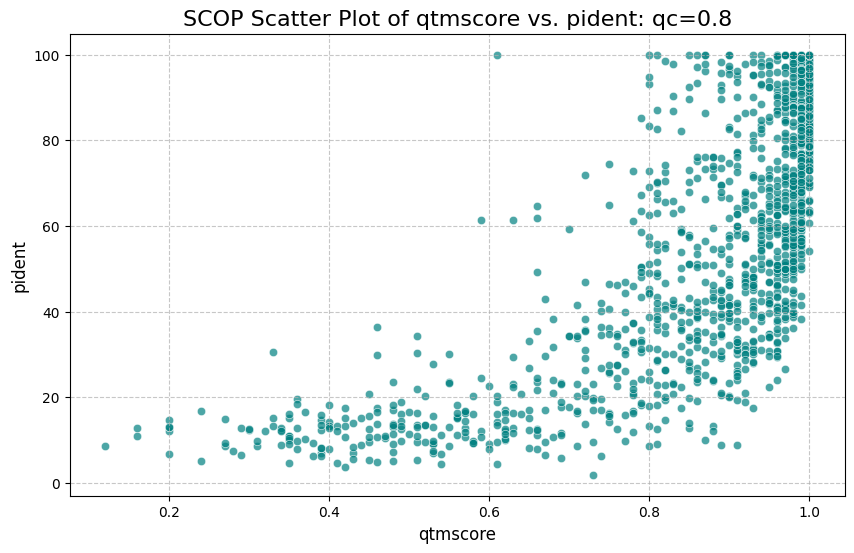

In [11]:
# Let's create a beautiful scatter plot of qtmscore vs. pident
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='qtmscore', y='pident', color='teal', alpha=0.7)
plt.title('SCOP Scatter Plot of qtmscore vs. pident: qc=0.8', fontsize=16)
plt.xlabel('qtmscore', fontsize=12)
plt.ylabel('pident', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

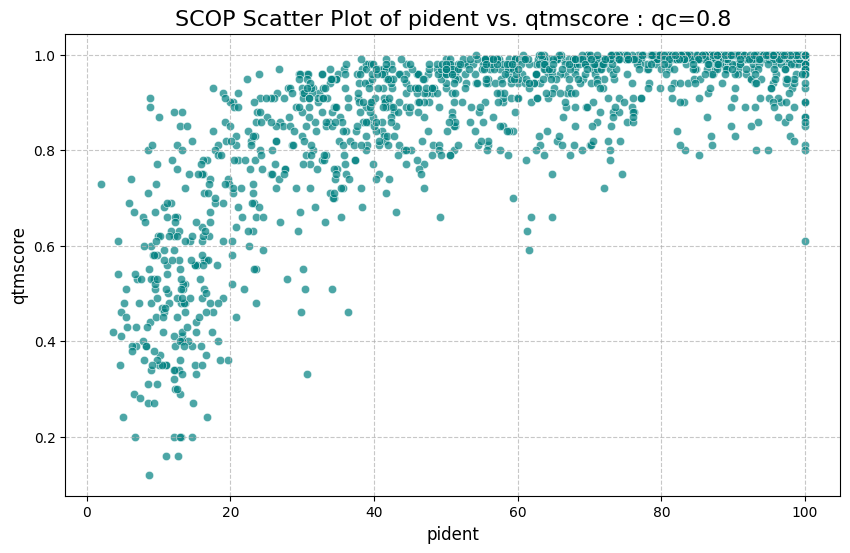

In [12]:
# Let's create a beautiful scatter plot of qtmscore vs. pident
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pident', y='qtmscore', color='teal', alpha=0.7)
plt.title('SCOP Scatter Plot of pident vs. qtmscore : qc=0.8', fontsize=16)
plt.xlabel('pident', fontsize=12)
plt.ylabel('qtmscore', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [13]:
# Calculate correlation between qtmscore and pident
correlation = df[['qtmscore', 'pident']].corr().iloc[0, 1]
print(f"Correlation between qtmscore and pident: {correlation:.4f}")

# Display basic statistics for these columns
print(df[['qtmscore', 'pident']].describe())

Correlation between qtmscore and pident: 0.7289
          qtmscore       pident
count  1359.000000  1359.000000
mean      0.858433    56.426269
std       0.182100    29.698930
min       0.120000     1.900000
25%       0.810000    31.050000
50%       0.940000    58.000000
75%       0.990000    83.850000
max       1.000000   100.000000


In [14]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   scop_query  1359 non-null   object 
 1   dpc_mcid    1359 non-null   object 
 2   dpc_target  1359 non-null   object 
 3   q_range     1359 non-null   object 
 4   t_range     1359 non-null   object 
 5   qlen        1359 non-null   int64  
 6   tlen        1359 non-null   int64  
 7   qcov        1359 non-null   float64
 8   tcov        1359 non-null   float64
 9   alnlen      1359 non-null   int64  
 10  qtmscore    1359 non-null   float64
 11  ttmscore    1359 non-null   float64
 12  alntmscore  1359 non-null   float64
 13  lddt        1359 non-null   float64
 14  pident      1359 non-null   float64
dtypes: float64(7), int64(3), object(5)
memory usage: 159.4+ KB


In [15]:
# Hom many unique queries are there?
unique_queries = df["scop_query"].nunique()
print(f"Number of unique queries: {unique_queries}")
# How many unique MCIDs are there?
unique_mcids = df["dpc_mcid"].nunique()
print(f"Number of unique MCIDs: {unique_mcids}")
# Hom many unique targets are there?
unique_targets = df["dpc_target"].nunique()
print(f"Number of unique targets: {unique_targets}")

Number of unique queries: 1359
Number of unique MCIDs: 1245
Number of unique targets: 1354


In [16]:
# Frequency of each MCID
mcid_counts = df["dpc_mcid"].value_counts()
# Top 10 most common MCIDs
top_10_mcids = mcid_counts.head(10)
print("Top 10 most common MCIDs:")
print(top_10_mcids)

Top 10 most common MCIDs:
dpc_mcid
MC49953    9
MC61388    7
MC18709    6
MC35185    3
MC41105    3
MC34978    3
MC30283    3
MC8570     3
MC53388    3
MC30379    3
Name: count, dtype: int64


In [17]:
# We save the cleaned dataset as a csv file
output_path = "/u/mdmc/enyanduk/internship_areasciencepark/Dataframes/DPCStruct/cleaned_annotated_scop_qc0.8_t0.5_l0.5.csv"
df.to_csv(output_path, index=False)